## **04. Submission & Inference - Conversion Rate Challenge**

**Objectif** : appliquer le pipeline final sur `data_test.csv` et générer le fichier de soumission.

**Modèle utilisé** : XGBoost entraîné en notebook 03  
**Seuil optimisé** : 0.95 (F1 = 0.7706 sur validation)

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

output_model_path = '../outputs/models'
output_data_path = '../outputs/data'
output_processed_path = '../outputs/processed'
output_image_path = '../outputs/images'

### **1. Chargement du modèle et des données**

In [4]:
# Chargement du meilleur modèle sauvegardé
with open(f'{output_model_path}/best_model.pkl', 'rb') as f:
    saved = pickle.load(f)

model = saved['model']
threshold = saved['threshold']
name = saved['name']

print(f'Modèle : {name}')
print(f'Seuil : {threshold:.2f}')

# X_test déjà preprocessé
X_test = np.load(f'{output_processed_path}/X_test.npy')
print(f'X_test: {X_test.shape}')

Modèle : XGBoost
Seuil : 0.95
X_test: (31620, 8)


### **2. Génération des prédictions**

In [5]:
# Probabilités de conversion
y_proba_test = model.predict_proba(X_test)[:, 1]

# Prédictions binaires avec le seuil optimisé
y_pred_test = (y_proba_test >= threshold).astype(int)

print('Distribution des prédictions :')
print(f'Non convertis (0) : {(y_pred_test==0).sum():,} ({(y_pred_test==0).mean()*100:.2f}%)')
print(f'Convertis (1) : {(y_pred_test==1).sum():,} ({(y_pred_test==1).mean()*100:.2f}%)')
print(f'\nTaux de conversion prédit : {y_pred_test.mean()*100:.2f}%')
print(f'Taux observé en train : 3.23%  (cohérent)')

Distribution des prédictions :
Non convertis (0) : 30,679 (97.02%)
Convertis (1) : 941 (2.98%)

Taux de conversion prédit : 2.98%
Taux observé en train : 3.23%  (cohérent)


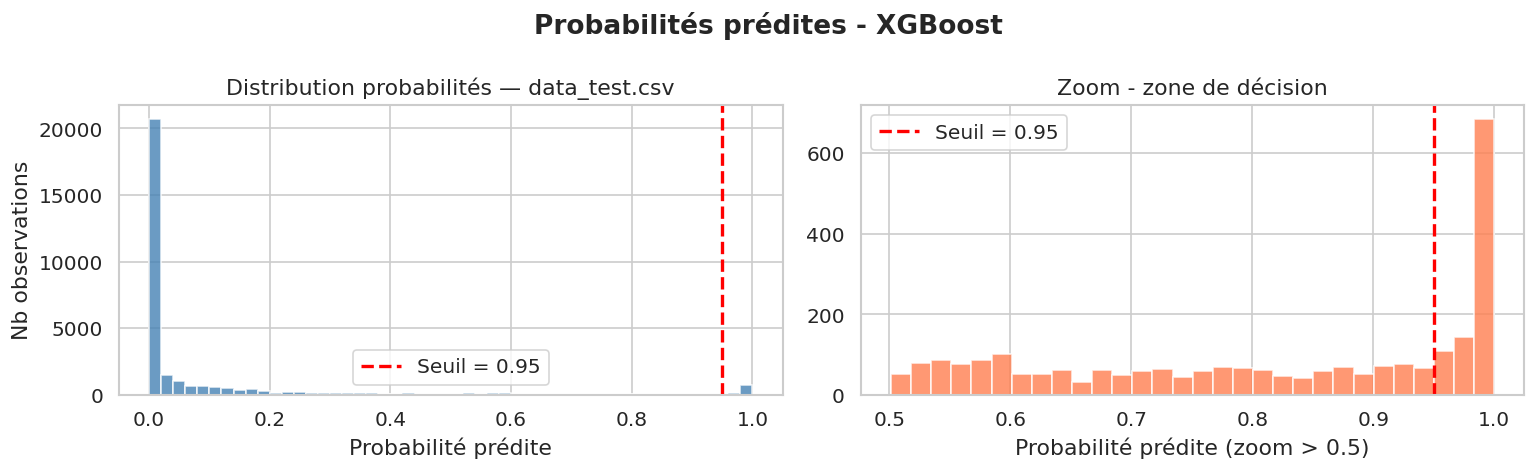

In [7]:
# Distribution des probabilités
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y_proba_test, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(threshold, color='red', linestyle='--', linewidth=2,
                label=f'Seuil = {threshold:.2f}')
axes[0].set_xlabel('Probabilité prédite'); axes[0].set_ylabel('Nb observations')
axes[0].set_title('Distribution probabilités — data_test.csv'); axes[0].legend()

axes[1].hist(y_proba_test[y_proba_test > 0.5], bins=30,
             color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(threshold, color='red', linestyle='--', linewidth=2,
                label=f'Seuil = {threshold:.2f}')
axes[1].set_xlabel('Probabilité prédite (zoom > 0.5)')
axes[1].set_title('Zoom - zone de décision'); axes[1].legend()

plt.suptitle(f'Probabilités prédites - {name}', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{output_image_path}/s01_proba_distribution.png', bbox_inches='tight')
plt.show()

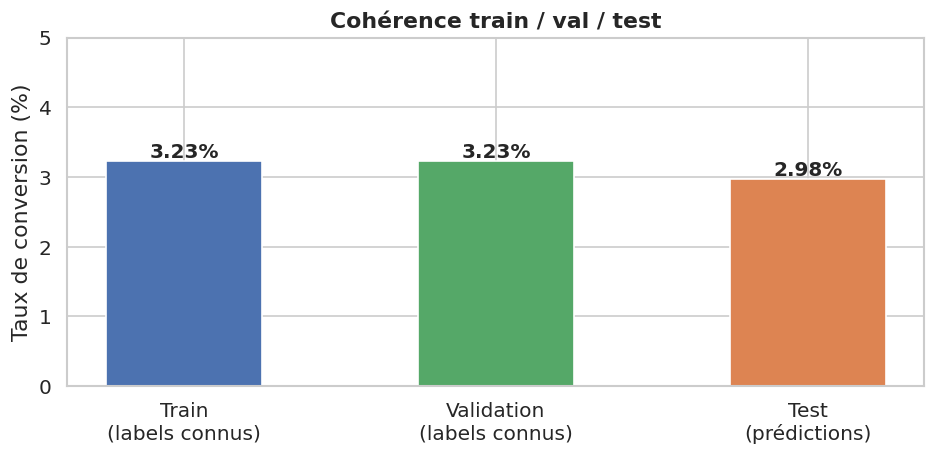

In [8]:
# Vérification de cohérence train / val / test
fig, ax = plt.subplots(figsize=(8, 4))
rates = [3.23, 3.23, y_pred_test.mean()*100]
bars = ax.bar(['Train\n(labels connus)', 'Validation\n(labels connus)', 'Test\n(prédictions)'],
              rates, color=['#4C72B0','#55A868','#DD8452'], edgecolor='white', width=0.5)

for bar, v in zip(bars, rates):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.05, f'{v:.2f}%',
            ha='center', fontsize=12, fontweight='bold')
            
ax.set_ylabel('Taux de conversion (%)'); ax.set_ylim(0, 5)
ax.set_title('Cohérence train / val / test', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{output_image_path}/s02_rates_comparison.png', bbox_inches='tight')
plt.show()

### **3. Export du fichier de soumission**

In [9]:
submission = pd.DataFrame({'converted': y_pred_test})
submission.to_csv(f'{output_data_path}/conversion_data_test_predictions_Raphael-model3.csv', index=False)

print(f'{output_data_path}/conversion_data_test_predictions_Raphael-model3.csv')
print(f'Lignes : {len(submission):,}')
print(f'Convertis prédits : {submission["converted"].sum():,}')
print()
print('Aperçu (10 premières lignes) :')
display(submission.head(10))

../outputs/data/conversion_data_test_predictions_Raphael-model3.csv
Lignes : 31,620
Convertis prédits : 941

Aperçu (10 premières lignes) :


,converted
0,1
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


### **4. Récapitulatif de la soumission**

- **Modèle** : XGBoost (300 estimateurs, max_depth=5)
- **Seuil de décision** : 0.95 (optimisé sur F1)
- **F1-score validation** : **0.7706**
- **ROC-AUC validation** : 0.9855
- **Convertis prédits (test)** : 941 / 31 620 (2.98%)
- **Fichier soumis** : `conversion_data_test_predictions_Raphael-model3.csv`